## Intracluster Medium Example

This notebook includes a practical example: downloading thermal Sunyaev-Zeldovich effect data and estimating the power spectral density of the observed surface brightness fluctuations.

This notebook requires `healpy` and `astropy` to project the data onto a 2D grid.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath('../../../'))
# Utility to make plots look nice
from kea.utils.plotting import modify_latex_rc, make_ax_step, pretty_axes
from kea.utils import binning
# modify_latex_rc()
# modify_latex_rc()
# Use the GPU for computing the SF, ACF, and performing Gaussian convolutions
from kea.utils import set_calculation_mode
set_calculation_mode(use_cpu=False, use_gpu=True)

Set statistic function calculation flags: (<CalculationMode.USE_GPU: 1>,)


(<CalculationMode.USE_GPU: 1>,)

First, download thermal SZ-effect data from the Planck archive.

In [ ]:
## Download 
from astropy.io import fits
from astropy.utils.data import download_file
url = 'http://pla.esac.esa.int/pla/aio/product-action?MAP.MAP_ID=COM_CompMap_Compton-SZMap-milca-ymaps_2048_R2.00.fits'
try:
    print('downloading file')
    file_path = download_file(url, cache=True)
    # hdul = fits.open(file_path)
except:
    print('Could not download file')

downloading file


In [22]:
## Import various libraries and utilities that we will be using
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import astropy.units as u
from astropy.io import fits
from astropy.nddata import Cutout2D
import healpy as hp
import cmasher
import seaborn as sns
from matplotlib.colors import LogNorm

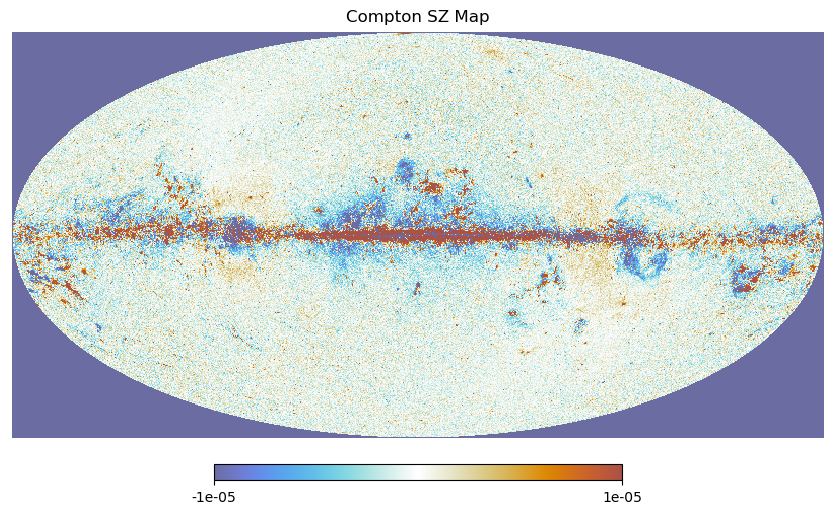

In [9]:
## Read full-sky ymap
ymap, header = hp.read_map(file_path, hdu=1, h=True)
## Plot to examine
hp.mollview(ymap, min=-1e-5, max=1e-5, cmap=cmasher.prinsenvlag_r, title='Compton SZ Map')

In [11]:
# Various Coma cluster information, and Planck information
loc = SkyCoord("194.953d  27.9806d", frame="icrs", unit="deg")
coma_z = 0.023
FWHM_planck = 10.*u.arcmin
map_fov = 6.*u.deg
map_reso = 0.5*u.arcmin
FWHM2sigma = 1./(2.*np.sqrt(2.*np.log(2.)))

In [ ]:
## Extract/project the 2D Coma cluster location
image = hp.gnomview(
    ymap,
    coord=('G', 'C'),
    rot=(loc.ra.value, loc.dec.value, 0.),
    xsize=360,
    ysize=360,
    reso=map_reso.value,
    cmap=cmasher.prinsenvlag_r,
    return_projected_map=True,
    min=-1e-5, max=1e-5,
    no_plot=True,
)

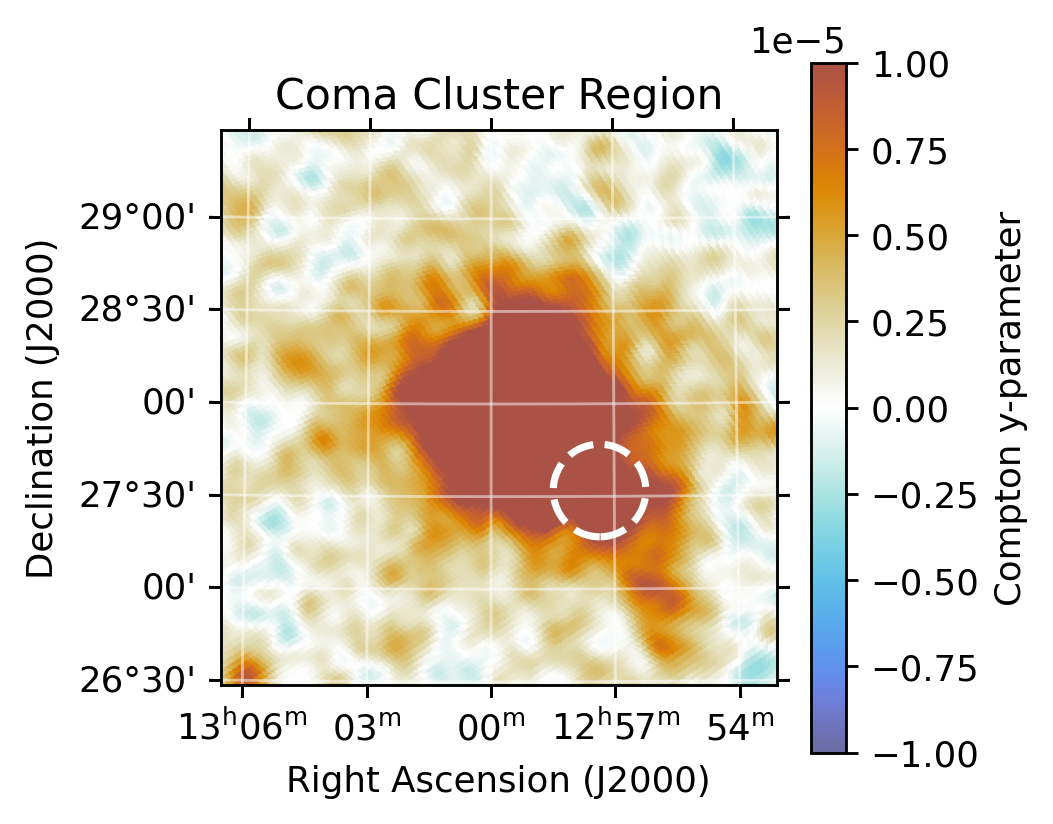

In [26]:
import matplotlib.pyplot as plt
from astropy.visualization.wcsaxes import SphericalCircle

# Define the WCS header manually
w = WCS(naxis=2)

# CRPIX: The reference pixel (center of your 360x360 image)
# Astropy uses 1-based indexing for CRPIX
w.wcs.crpix = [180.5, 180.5]

# CDELT: Pixel scale in degrees
# RA is usually negative to keep East on the left
w.wcs.cdelt = np.array([-map_reso.to(u.deg).value, map_reso.to(u.deg).value])

# CRVAL: The sky coordinates at the reference pixel
w.wcs.crval = [loc.ra.value, loc.dec.value]

# CTYPE: The projection type (Gnomonic/Tangent)
w.wcs.ctype = ["RA---TAN", "DEC--TAN"]

# Set the coordinate frame
w.wcs.equinox = 2000.0

# Define NGC 4839 coordinates
ngc_coords = SkyCoord("12h57m21.5s", "+27d31m54s", frame='icrs')

fig = plt.figure(figsize=(3.5, 3.5), dpi=256)

# Initialize plot with WCS projection
ax = fig.add_subplot(1, 1, 1, projection=w)

# Plot the image (returned from your gnomview call)
im = ax.imshow(image, origin='lower', cmap=cmasher.prinsenvlag_r, 
               vmin=-1e-5, vmax=1e-5)

# NGC 4839 (infalling group)
# Overlay the 15 arcmin circle using sky coordinates
# SphericalCircle handles the projection geometry correctly
circle = SphericalCircle(ngc_coords, 15 * u.arcmin, 
                         edgecolor='white', facecolor='none', 
                         lw=2, ls='--', transform=ax.get_transform('icrs'))
ax.add_patch(circle)

# Add coordinate grids and labels
ax.coords.grid(color='white', alpha=0.5, linestyle='solid')
ax.coords['ra'].set_axislabel('Right Ascension (J2000)')
ax.coords['dec'].set_axislabel('Declination (J2000)')

plt.colorbar(im, label='Compton y-parameter')
plt.title(f"Coma Cluster Region")

plt.show()

We assume that the ICM profile consists of an unperturbed profile and the (turbulence) fluctuations.

We generate a simple symmetric beta model to act as the unperturbed profile.

In [ ]:
## Unperturbed model
grid = np.indices(np.shape(image))
def beta_model(params):
    I0 = params[0]
    cx = params[1]
    cy = params[2]
    c = [cx,cy]
    rc = params[3]
    beta = params[4]
    r = np.linalg.norm([grid[i,...] - c[i] for i in range(len(np.shape(image)))], axis=0)
    return I0 / (1. + (r/rc)**2)**(beta)
## Parameters found by MCMC
## (add your own profile parameters!)
I0 = 6.364e-5
cx = 174.5
cy = 190.179
rc = 41.404
beta = 1.363
mean_profile = beta_model([I0, cx, cy, rc, beta])

Text(0.5, 1.0, 'Fluctuations')

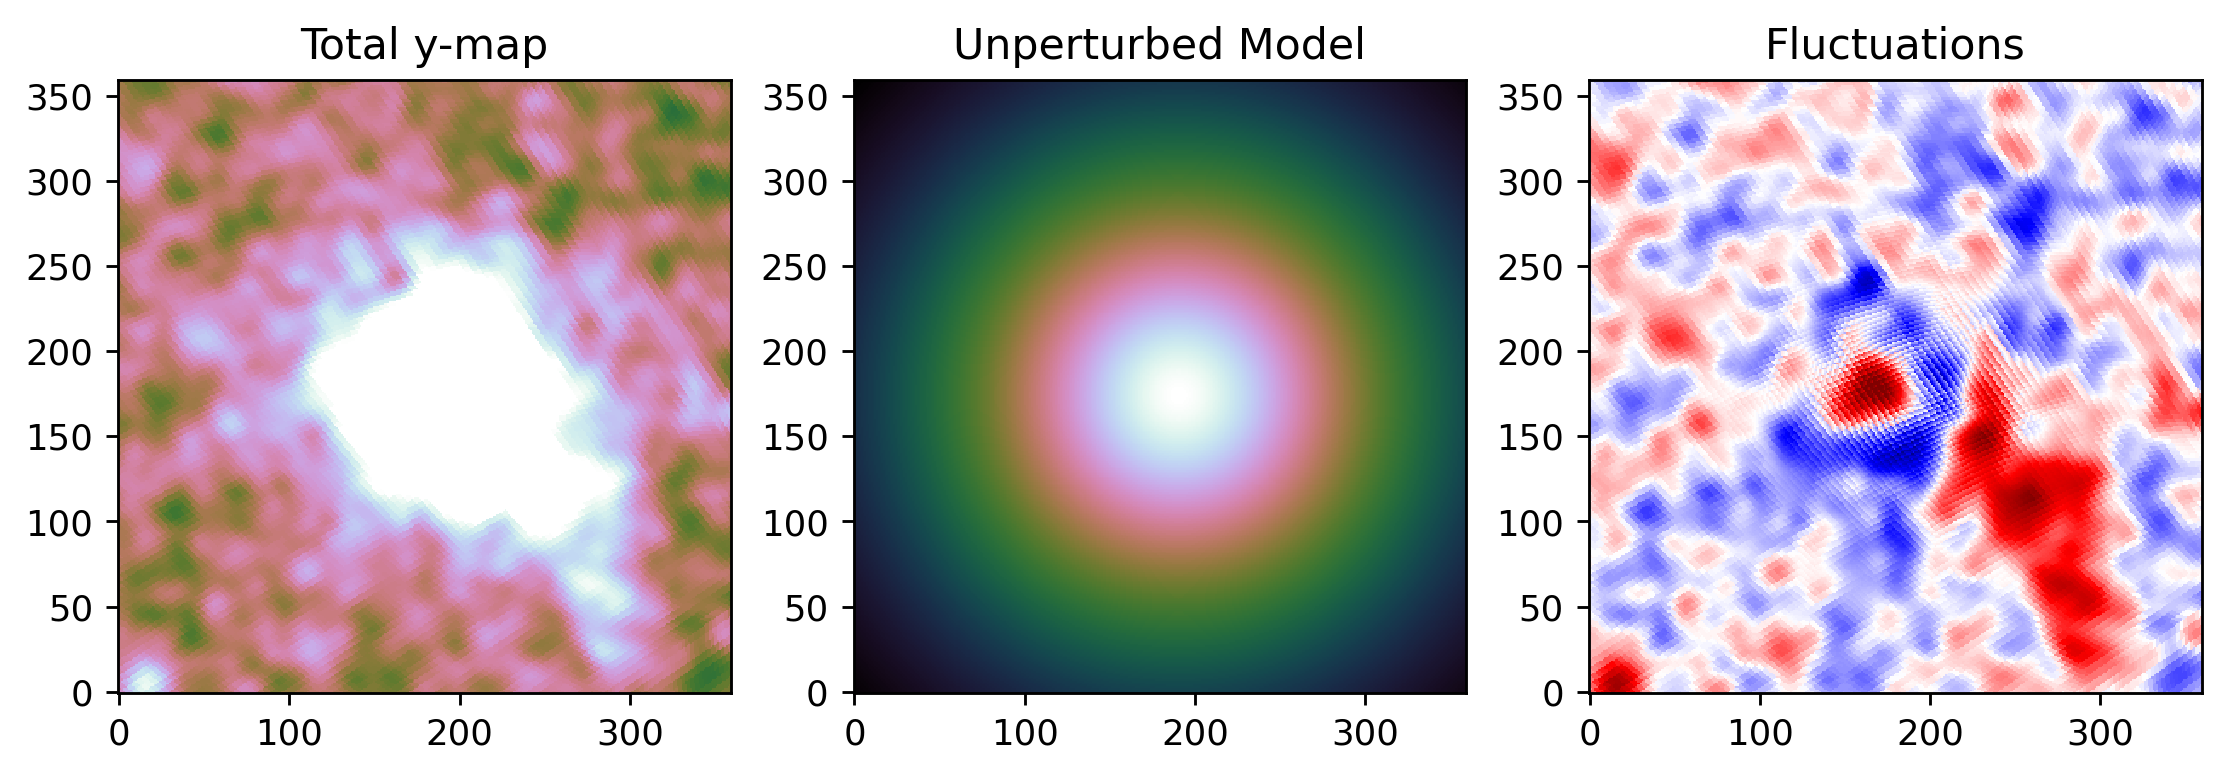

In [24]:
## Plot observation
fig, ax = plt.subplots(1, 3, figsize=(3.5*3., 3.5), dpi=256)
cmap = sns.color_palette('cubehelix', as_cmap=True)
cmap.set_bad('black')
ax[0].imshow(image, origin='lower', cmap=cmap, aspect='equal', vmin=-1e-5, vmax=1e-5, interpolation='none')
ax[0].set_title('Total y-map')
ax[1].imshow(mean_profile, origin='lower', cmap=cmap, aspect='equal', norm=LogNorm(), interpolation='none')
ax[1].set_title('Unperturbed Model')
ax[2].imshow((image - mean_profile), origin='lower', cmap='seismic', aspect='equal', vmin=-1e-5, vmax=1e-5, interpolation='none')
ax[2].set_title('Fluctuations')

/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3748: FutureWarning: Passing 'z' as keyword is deprecated since version 7.0 and will stop working in a future release. Pass it positionally to suppress this warning.
  exec(code_obj, self.user_global_ns, self.user_ns)


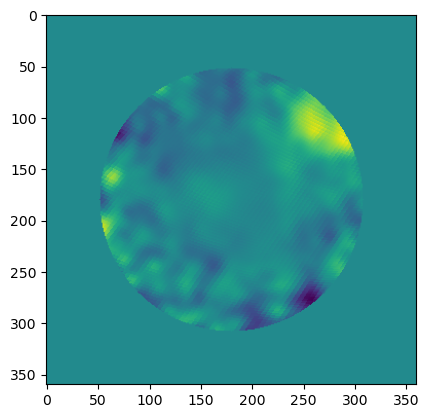

In [71]:
## Get physical domain of the observation
from astropy.cosmology import Planck18 as cosmo
dtheta = map_reso
d_A = cosmo.angular_diameter_distance(z=0.023)
dx_phys = (dtheta * d_A).to(u.kpc, u.dimensionless_angles())
L_phys = (dx_phys * np.float64(np.shape(image)[0])).value
L_theta = (dtheta * np.float64(np.shape(image)[0])).value
## Grid dimensions
D = 2
N = np.shape(image)[0]
grid_dims = (N,)*D
from kea.utils import geometry
geometry.DEFAULT_PHYS_SCALE = L_phys
## turbulence fluctuations
delta = (image - mean_profile)/mean_profile
pos = (N//2, N//2)
grid = np.indices(grid_dims)
r = np.linalg.norm([grid[i,...] - pos[i] for i in range(len(grid_dims))], axis=0)
delta[r>128] = 0.
plt.imshow(delta)

Text(0.5, 0, 'Wavenumber [kpc$^{-1}$]')

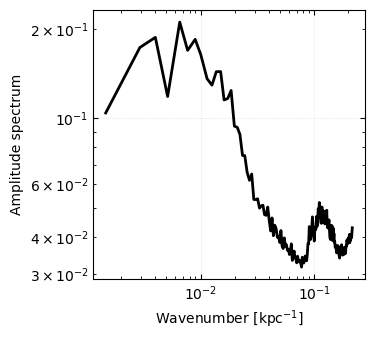

In [73]:
## Calculate spectrum
from kea.statistics.spectra import fourier_modal_spectrum, bin_spectrum, transform_spectrum
kvec, modal_spectrum = fourier_modal_spectrum(delta)
kp, fekp, bin_widths = bin_spectrum(kvec, modal_spectrum, 'integrated')
## Calculate the amplitude spectrum -- commonly used in ICM analyses
k, amp = transform_spectrum(kp, fekp, 3, 'integrated', 'amplitude', grid_dims, bin_widths=bin_widths, is_centered=True)
## Plot spectrum
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(k, amp/L_phys, linewidth=2., linestyle='-', color='black')
ax.set_yscale('log')
ax.set_xscale('log')
pretty_axes(ax)
ax.set_ylabel('Amplitude spectrum')
ax.set_xlabel('Wavenumber [kpc$^{-1}$]')